ML Assignment -1

Dataset: Titanic Dataset (titanic_data_updated.csv)

Total Marks: 100

Email: pretabinda@gmail.com

Name: Preta Kumar Binda

Exam Instructions :
- প্রথমে একটি Google Colab ফাইল খুলবে , এরপর প্রথম cell এ নিজের নাম এবং কোর্সে registration করা ইমেইল দিবে
- Question wise numbering করে Text cell রাখবে এবং এর নিচে Code cell থাকবে, চেষ্টা করবে একটি code cell এ একটি question উত্তর দেয়ার
- Google colab এর মধ্যে কোডগুলো করবে
- এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।


# Question 1 (10 Marks)
Load the Titanic dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [ ]:
import pandas as pd
df = pd.read_csv('titanic_data_updated.csv')
print(df.shape)
print(df.head(10))
print(df.sample(5))

(891, 12)
   PassengerId Survived  Pclass  \
0            1       no   third   
1            2      yes   first   
2            3      yes   third   
3            4      yes   first   
4            5       no   third   
5            6       no   third   
6            7       no   first   
7            8       no   third   
8            9      yes   third   
9           10      yes  second   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54.

# Question 2 (10 Marks)
Perform feature screening on the Titanic dataset by:
- Finding total missing values
- Finding duplicate rows
- Removing duplicate rows permanently

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
0


# Question 3 (10 Marks)
Perform statistical profiling of the Titanic dataset and display:
- Dataset information
- Statistical summary of numerical columns

Also write 2 observations from the output.


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB
None
       PassengerId         Age       SibSp       Parch        Fare
count   891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000   29.699118    0.523008    0.381594   32.204208
std     257.353842   14.526497    1.10

### <font color='red'> 2 Observations:</font>
- Age and Cabin column has null values
- Fare has a max value of 512.32 but 75% has value around 31.00. So, it has outliers.

# Question 4 (10 Marks)
Perform univariate categorical analysis on the Survived column by:
- Creating a countplot
- Calculating percentage distribution
- Creating a pie chart

Write 2 insights from the analysis.

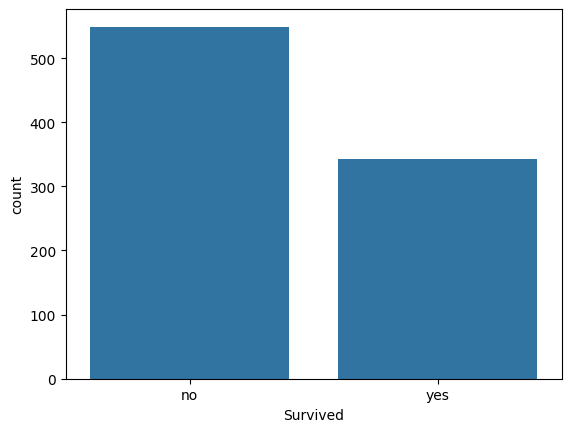

Calculating percentage distribution:
Survived
no     61.616162
yes    38.383838
Name: proportion, dtype: float64
Creating a pie chart:


([<matplotlib.patches.Wedge at 0x7f4c995eaab0>,
 [Text(-0.39257494735793463, 1.0275626067091557, 'no'),
  Text(0.3925749146953058, -1.0275626191877425, 'yes')],
 [Text(-0.21413178946796432, 0.5604886945686304, '61.6%'),
  Text(0.21413177165198496, -0.5604887013751322, '38.4%')])

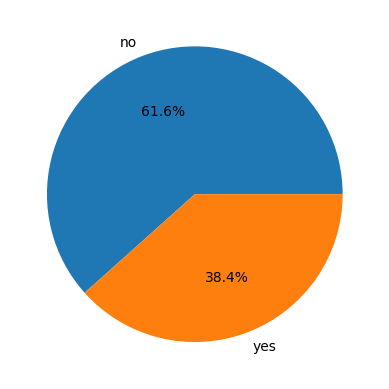

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='Survived')
plt.show()
print('Calculating percentage distribution:')
print(df['Survived'].value_counts(normalize=True)*100)
print('Creating a pie chart:')
plt.pie(df['Survived'].value_counts(), labels=df['Survived'].value_counts().index, autopct='%1.1f%%')

## <font color="red">Two insights:</font>
- 61.6 % people was dead. that means more than half people was dead
- the chance of remain alive was nearly one third.

# Question 5 (10 Marks)
Perform univariate numerical analysis on the Age column by:
- Creating a histogram
- Creating a KDE plot

Write 2 observations from the plots.


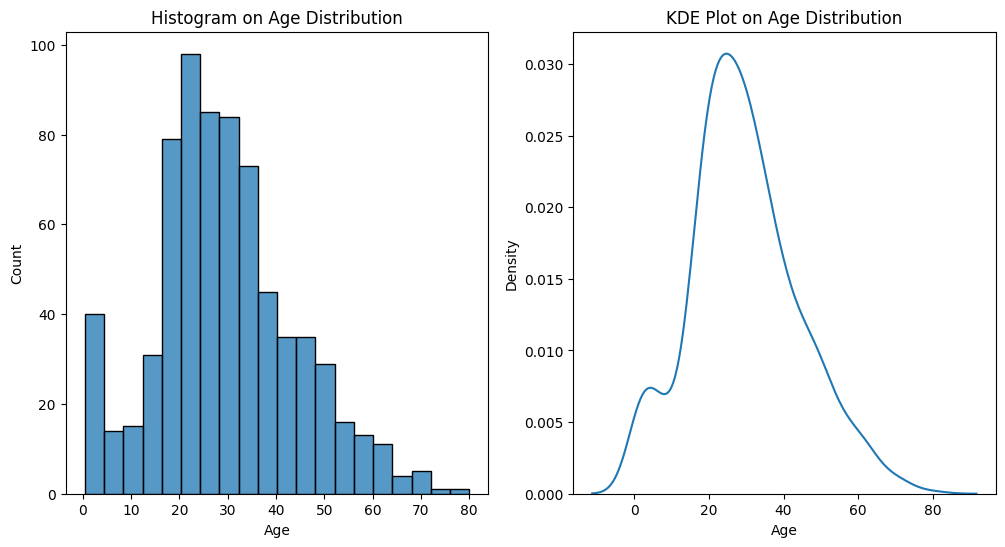

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(data=df, x='Age')
plt.title('Histogram on Age Distribution')

plt.subplot(1,2,2)
sns.kdeplot(data=df, x='Age')
plt.title('KDE Plot on Age Distribution')
plt.show()

## <font color='red'> 2 Observations:  </font>
- Most of the peoples are aged between 15 to 35
- There are some people who are aged 70+, making the distribution right skewed.

# Question 6 (10 Marks)
Perform multivariate analysis between Sex and Survived using a countplot with hue.

Also calculate normalized survival ratios using groupby().

Write 2 insights from the analysis.


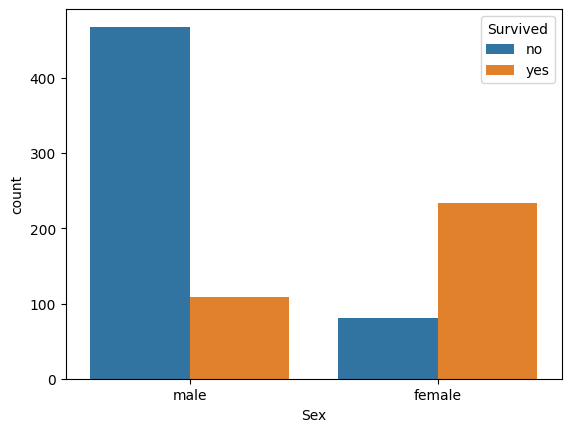

normalized survival ratios:
Sex     Survived
female  yes         74.203822
        no          25.796178
male    no          81.109185
        yes         18.890815
Name: proportion, dtype: float64


In [ ]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.show()

print('normalized survival ratios:')
print(df.groupby('Sex')['Survived'].value_counts(normalize=True)*100)

## <font color='red'>2 Observations:</font>
- Females survived more than Male.
- The survival ratio of male vs female is nearly 1:4.

# Question 7 (10 Marks)

Create a barplot showing the relationship between Pclass and Fare.

Write 2 observations from the visualization.


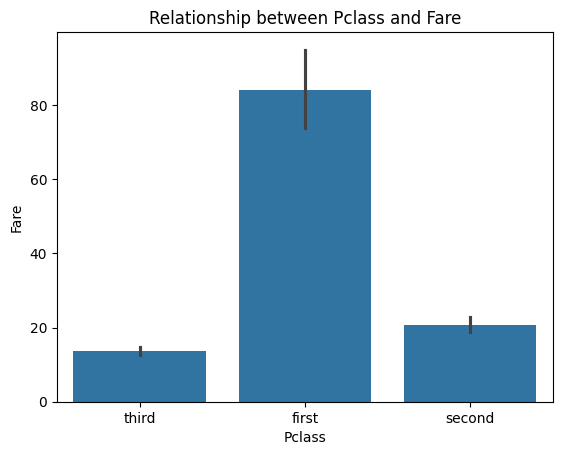

In [ ]:
sns.barplot(data=df, x='Pclass', y='Fare')
plt.title('Relationship between Pclass and Fare')
plt.show()


## <font color='red'> 2 Observations </font>
- Peoples of First class are giving more fare than the second and third class peoples.
- first class has a higher confidance interval then the others. representing people in there paid different number of fares. on the other hand in the other classes, people paid almost constant amount of fares.

# Question 8 (10 Marks)

Create a KDE plot to compare the Age distribution of survived and non-survived passengers.

Write 2 insights from the graph.


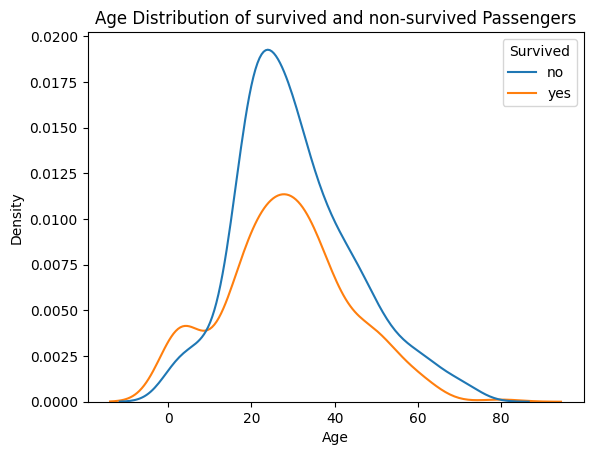

In [ ]:
sns.kdeplot(data=df, x='Age', hue='Survived')
plt.title('Age Distribution of survived and non-survived Passengers')
plt.show()

## <font color='red'> 2 Observations </font>
- some people aged more than 80 maybe survived as the orange curve indicating. And also survival density of childs are bigger than non-survival rate.
- Non survival density is more than survival density. That means more people died than the people survived.


# Question 9 (10 Marks)
Perform feature engineering and train-test split by:
- Dropping PassengerId, Name, and Ticket columns
- Separating features (X) and target (y)
- Splitting the dataset using test_size=0.2 and random_state=42

Display the shapes of train and test datasets.


In [ ]:
df1 = df.copy()
df1.drop(['PassengerId','Name', 'Ticket'], axis=1, inplace=True)

X= df1.drop('Survived', axis=1)
y = df1['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


# Question 10 (10 Marks)
Handle missing values in the Titanic dataset by:
- Imputing missing Age values using SimpleImputer with mean strategy
- Imputing missing Embarked values using most frequent strategy
- Imputing missing Cabin values using constant strategy with "Missing"

Finally, check whether any missing values remain.


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train[['Age']])
X_train['Age'] = imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = imputer.transform(X_test[['Age']]).ravel()

imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = imputer.transform(X_test[['Embarked']]).ravel()

imputer = SimpleImputer(strategy='constant', fill_value="Missing")
imputer.fit(X_train[['Cabin']])
X_train['Cabin'] = imputer.transform(X_train[['Cabin']]).ravel()
X_test['Cabin'] = imputer.transform(X_test[['Cabin']]).ravel()

print(X_train.isnull().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64
